# Analyze DPL Results

In [1]:
from pathlib import Path
import pickle
import json

import pandas as pd
import numpy as np

from temp import (
    mis_metrics,
    plot_mis_predictions
)

## Configuration

### DARPA 2000

In [53]:
# dataset = "darpa2000"
# scenario = "s1_inside"

# logic_file = "darpa"
# logic_file = "darpa_logic_baseline"

### AIT-LDSv2

In [54]:
dataset = "aitv2"
scenario = "fox"
scenario = "santos"

logic_file = "ait"
# logic_file = "ait_logic_baseline"

## Load Original Flows

In [55]:
df = pd.read_csv(
    f"../data/interim/{dataset}/{scenario}/flows_labeled/all_flows_labeled.csv"
)

df = df.sort_values("start_time").reset_index(drop=True)
df['t_rel'] = df['start_time'] - df['start_time'].min()

In [56]:
phase_bounds = (
    df[df['phase'] > 0]
    .groupby('phase')['t_rel']
    .agg(['min', 'max'])
)

phase_start = phase_bounds['min'].to_dict()
phase_end   = phase_bounds['max'].to_dict()

In [57]:
phase_bounds

,min,max
phase,,
1,299710.474974,300162.491487
2,300174.736570,300251.641905
3,300253.783838,302244.616236
4,7.305590,198962.549623


## Load DPL Dataset

In [58]:
def load_dpl_dataset(logic_file, cache_file_name):
    dpl_dataset_dir = Path(f"../experiments/{dataset}/{scenario}/deepproblog/{logic_file}/cache/")
    cache_file_test = dpl_dataset_dir / cache_file_name

    cache = pickle.load(open(cache_file_test, "rb"))
    cache_df = pd.DataFrame(cache)
    cache_df.head()

    return cache_df

## Load DPL Metrics

In [59]:
phase_map = {
    "benign": 0,
    "phase1": 1,
    "phase2": 2,
    "phase3": 3,
    "phase4": 4,
    "phase5": 5,
}

In [60]:
experiments = {}

# --- Load metrics ---
metrics_dir = Path(f"../experiments/{dataset}/{scenario}/deepproblog/{logic_file}/metrics")
file_paths = list(metrics_dir.iterdir())
    
for file_path in file_paths:
    experiment_name = str(file_path.stem)

    # Metrics
    print(f"Processing {experiment_name}...")
    data = np.load(file_path, allow_pickle=True)
    print(experiment_name)
    experiments[experiment_name] = {
        "confusion_matrix": data["confusion_matrix"],
        "classes": data["classes"].tolist(),
        "metrics": data["metrics"].item(),
    }

Processing ait_scratch_behavioral_w10_1000b1000a_20260426_135204...
ait_scratch_behavioral_w10_1000b1000a_20260426_135204
Processing ait_scratch_reduced_w10_1000b1000a_20260426_142318...
ait_scratch_reduced_w10_1000b1000a_20260426_142318
Processing ait_scratch_reduced_w10_10000b10000a_20260426_140247...
ait_scratch_reduced_w10_10000b10000a_20260426_140247


## Analyze Results

In [61]:
plots_dir = Path(f"../reports/{dataset}/{scenario}")

Processing logic file: ait
ait_scratch_behavioral_w10_1000b1000a_20260426_135204
Experiment: ait_scratch_behavioral_w10_1000b1000a_20260426_135204
Saving plot to ../reports/aitv2/santos/deepproblog/ait/temporality...
ait_scratch_reduced_w10_1000b1000a_20260426_142318
Experiment: ait_scratch_reduced_w10_1000b1000a_20260426_142318
Saving plot to ../reports/aitv2/santos/deepproblog/ait/temporality...
ait_scratch_reduced_w10_10000b10000a_20260426_140247
Experiment: ait_scratch_reduced_w10_10000b10000a_20260426_140247
Saving plot to ../reports/aitv2/santos/deepproblog/ait/temporality...


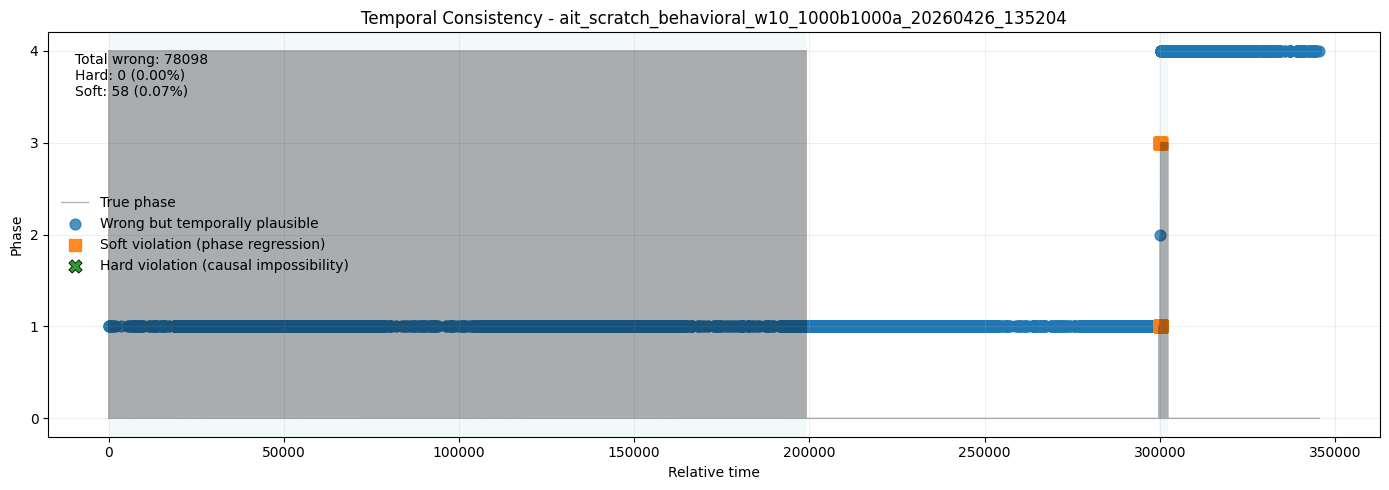

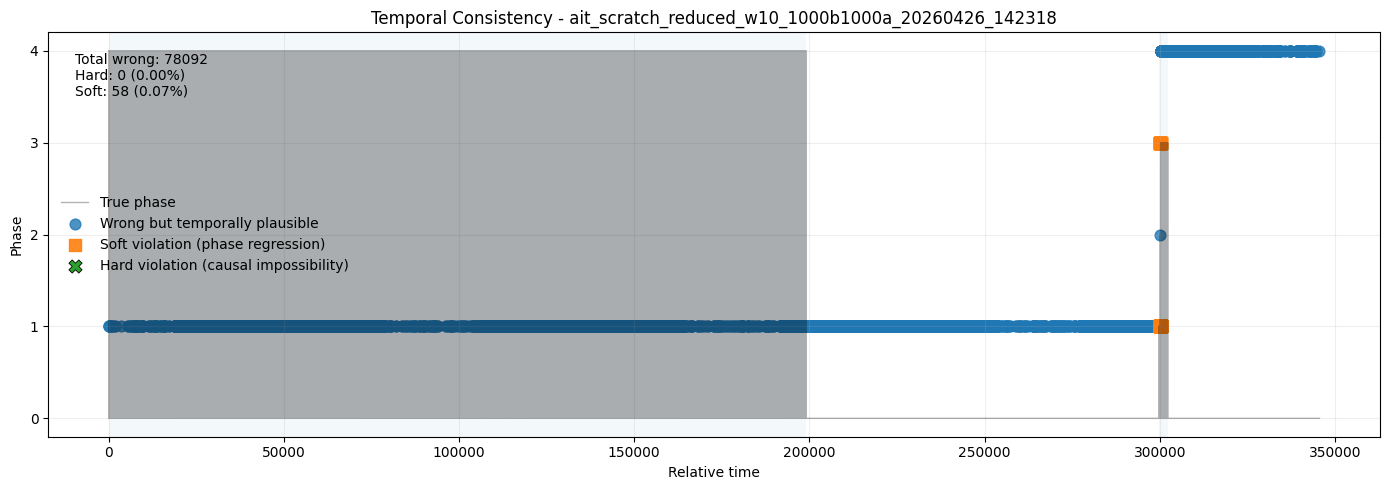

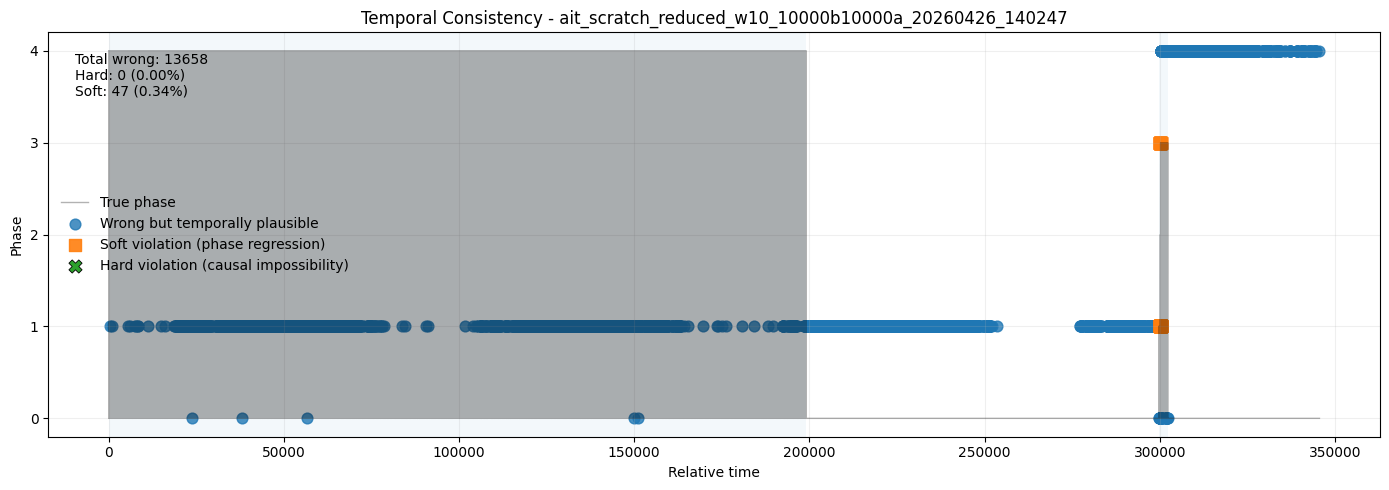

In [62]:
results = []

print(f"Processing logic file: {logic_file}")

# --- Load errors ---
err_folder = Path(f"../experiments/{dataset}/{scenario}/deepproblog/{logic_file}/errors/")
file_paths = list(err_folder.iterdir())

for file_path in file_paths:
    print(file_path.stem)
    experiment_name_full = str(file_path.stem)
    experiment_name = experiment_name_full[:-16] # Remove "run_id"
    parts = experiment_name.split("_")
    
    cache_file_name = f"{logic_file}_{parts[-2]}_{parts[-1]}_test.pkl"
    cache_df = load_dpl_dataset(logic_file, cache_file_name)

    with open(file_path, "r") as f:
        errors = json.load(f)
    
    dpl_to_orig = dict(zip(cache_df['dpl_index'], cache_df['orig_index']))

    original_indices = []
    mis_y_preds = []
    mis_y_trues = []

    for error in errors:
        dpl_index = error['index']
        original_indices.append(dpl_to_orig[dpl_index])

        y_pred = error['predicted']
        y_true = error['actual']
        mis_y_preds.append(phase_map[y_pred])
        mis_y_trues.append(phase_map[y_true])

    mis_df = df.loc[original_indices].copy()
    mis_df['y_pred'] = mis_y_preds
    mis_df['y_true'] = mis_y_trues

    # --- Compute violation categories ---
    wrong, hard, soft, plausible = mis_metrics(mis_df, phase_start)

    total_wrong = len(wrong)
    hard_rate = len(hard) / total_wrong if total_wrong > 0 else 0
    soft_rate = len(soft) / total_wrong if total_wrong > 0 else 0

    # --- Collect everything ---
    print(f"Experiment: {experiment_name_full}")
    metrics = experiments[experiment_name_full]['metrics']
    
    results.append({
        "model": f"{experiment_name_full}",
        "accuracy": metrics["accuracy"],
        "precision" : metrics["macro_precision"],
        "recall" : metrics["macro_recall"], 
        "f1": metrics["macro_f1"],
        "FPR": metrics["false_alarm_rate"],
        "Detection Rate": metrics["detection_rate"],
        "total_wrong": total_wrong,
        "hard_violations": len(hard),
        "soft_violations": len(soft),
        "hard_rate": hard_rate,
        "soft_rate": soft_rate,
    })

    # Create plots
    out_dir = plots_dir / "deepproblog" / logic_file / "temporality"
    out_dir.mkdir(parents=True, exist_ok=True)

    plot_mis_predictions(
        df, 
        phase_bounds, 
        plausible, 
        soft, 
        hard, 
        total_wrong, 
        soft_rate, 
        hard_rate, 
        file_path.stem, 
        out_dir, 
        save_plot=True,
        show_plot=False
    )


## Metrics for All Models

In [63]:
results_df = pd.DataFrame(results)
results_df

,model,accuracy,precision,recall,f1,FPR,Detection Rate,total_wrong,hard_violations,soft_violations,hard_rate,soft_rate
0,ait_scratch_behavioral_w10_1000b1000a_20260426...,0.446370,0.678772,0.883046,0.653208,0.584772,1.000000,78098,0,58,0.0,0.000743
1,ait_scratch_reduced_w10_1000b1000a_20260426_14...,0.446412,0.678773,0.883055,0.653218,0.584727,1.000000,78092,0,58,0.0,0.000743
2,ait_scratch_reduced_w10_10000b10000a_20260426_...,0.903073,0.725110,0.901430,0.758727,0.099257,0.944504,13658,0,47,0.0,0.003441


In [64]:
results_df["temporal_score"] = (
    results_df["f1"]
    - 0.5 * results_df["hard_rate"]
    - 0.2 * results_df["soft_rate"]
)

In [65]:
results_df_sorted_f1 = results_df.sort_values("f1", ascending=False)

# Save metrics to file
results_df_sorted_f1.to_csv(
    plots_dir / "deepproblog" / logic_file / "temporal_consistency.csv",
    index=False
)

In [66]:
results_df_sorted_f1.head(10)

,model,accuracy,precision,recall,f1,FPR,Detection Rate,total_wrong,hard_violations,soft_violations,hard_rate,soft_rate,temporal_score
2,ait_scratch_reduced_w10_10000b10000a_20260426_...,0.903073,0.725110,0.901430,0.758727,0.099257,0.944504,13658,0,47,0.0,0.003441,0.758038
1,ait_scratch_reduced_w10_1000b1000a_20260426_14...,0.446412,0.678773,0.883055,0.653218,0.584727,1.000000,78092,0,58,0.0,0.000743,0.653069
0,ait_scratch_behavioral_w10_1000b1000a_20260426...,0.446370,0.678772,0.883046,0.653208,0.584772,1.000000,78098,0,58,0.0,0.000743,0.653060


In [67]:
results_df_sorted_temp = results_df.sort_values("temporal_score", ascending=False)

results_df_sorted_temp.head()

,model,accuracy,precision,recall,f1,FPR,Detection Rate,total_wrong,hard_violations,soft_violations,hard_rate,soft_rate,temporal_score
2,ait_scratch_reduced_w10_10000b10000a_20260426_...,0.903073,0.725110,0.901430,0.758727,0.099257,0.944504,13658,0,47,0.0,0.003441,0.758038
1,ait_scratch_reduced_w10_1000b1000a_20260426_14...,0.446412,0.678773,0.883055,0.653218,0.584727,1.000000,78092,0,58,0.0,0.000743,0.653069
0,ait_scratch_behavioral_w10_1000b1000a_20260426...,0.446370,0.678772,0.883046,0.653208,0.584772,1.000000,78098,0,58,0.0,0.000743,0.653060
